# Quinquennial EDA: Economic Freedom + Macro Panel (1970-2020)

**Focus**: Long-run analysis aligned to EFW quinquennial waves.

No interpolation - uses only actual wave-year observations.

**Key outputs**:
- Convergence analysis (σ and β)
- Mobility analysis (transition matrices, rank persistence)
- Macro-conditioned reform comparisons

## 0. Configuration

In [15]:
import sys
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

%matplotlib inline

warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

from src import downloaders, harmonize, merge_efw, quality, plots

# Configuration
EFW_PATH = "data/fraser.xlsx"
QUINQUENNIAL_YEARS = [1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020]

CORE_MACRO = [
    'gdppc_filled',
    'NY.GDP.MKTP.KD.ZG',
    'FP.CPI.TOTL.ZG',
    'trade_openness_filled',
    'investment_gfcf_filled',
    'govt_consumption_filled',
]

EXTENDED_MACRO = [
    'SP.POP.TOTL',
    'SL.UEM.TOTL.ZS',
    'FS.AST.PRVT.GD.ZS',
    'BX.KLT.DINV.WD.GD.ZS',
    'BN.CAB.XOKA.GD.ZS',
    'GC.TAX.TOTL.GD.ZS',
    'GC.DOD.TOTL.GD.ZS',
    'FM.LBL.BMNY.GD.ZS',
    'kaopen',
    'kof_globalization',
    'wgi_control_corruption',
    'wgi_govt_effectiveness',
    'wgi_political_stability',
    'wgi_regulatory_quality',
    'wgi_rule_of_law',
    'wgi_voice_accountability',
    'gdppc_pwt_scaled',
    'trade_openness_pwt',
    'investment_share_pwt',
    'govt_consumption_share_pwt',
    'human_capital',
    'SE.SEC.ENRR',        # School enrollment, secondary
    'SI.POV.GINI',        # Gini index
    'SP.DYN.LE00.IN',     # Life expectancy
    'NY.GDP.TOTL.RT.ZS',  # Natural resources rents
    'SL.TLF.CACT.ZS',     # Labor force participation
    'gdppc_maddison',     # Maddison Project GDP
    'years_schooling',    # Barro-Lee Years of Schooling
]

ANALYSIS_MACRO = CORE_MACRO + EXTENDED_MACRO

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

plots.setup_plot_style()
print("Quinquennial EDA Configuration")
print(f"Waves: {QUINQUENNIAL_YEARS}")

Quinquennial EDA Configuration
Waves: [1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020]


## 1. Data Loading

In [16]:
print("=" * 60)
print("STEP 1: LOAD DATA")
print("=" * 60)

# Download macro data (cached)
df_macro_long = downloaders.download_all_sources(
    force_download=False,
    include_secondary=True,
    verbose=True
)

# Load EFW
df_efw = merge_efw.load_efw(EFW_PATH, verbose=True)

STEP 1: LOAD DATA
DOWNLOADING MACRO DATA FROM MULTIPLE SOURCES
  Force download: False
  Include secondary sources: True

Loading WDI from cache: data/raw/wdi_data.parquet
Loading PWT from cache: data/raw/pwt_data.parquet
Loading WGI from cache: data/raw/wgi_data.parquet

DOWNLOAD SUMMARY
Total observations: 343,138
Countries: 265
Variables: 38
Years: 1950-2024

By source:
source
PWT    121656
WDI    191410
WGI     30072
Loaded Fraser EFW data:
  Observations: 4,950
  Years: 1970–2023
  Countries: 165
Loaded EFW: 4,950 obs, 165 countries


## 2. Build Quinquennial Panel

In [17]:
print("\n" + "=" * 60)
print("STEP 2: BUILD QUINQUENNIAL PANELS")
print("=" * 60)

# Build concordance for name-based sources
name_to_iso3, concordance_df = harmonize.build_iso3_concordance(
    df_efw,
    efw_iso_col='iso3',
    efw_name_col='Countries',
    verbose=True
)
harmonize.save_concordance(concordance_df)

# EFW quinquennial
df_efw_quin = merge_efw.get_efw_quinquennial(df_efw)
print(f"EFW quinquennial: {len(df_efw_quin):,} obs, {df_efw_quin['iso3'].nunique()} countries")

# Macro quinquennial (no interpolation)
df_macro_long['iso3'] = df_macro_long['iso3'].astype(str).str.strip()
df_macro_long['iso3'] = df_macro_long['iso3'].map(name_to_iso3).fillna(df_macro_long['iso3'])

df_macro_clean = harmonize.standardize_iso3(df_macro_long)

# IMPROVED: 5-Year Centered Averages for Quinquennial Data
# Instead of taking just the wave year, we take the average of [t-2, t+2]
# This reduces noise and improves coverage for structural variables.
print("Computing 5-year centered averages for macro data...")
quin_data = []

for target_year in QUINQUENNIAL_YEARS:
    # Define window [t-2, t+2]
    window_start = target_year - 2
    window_end = target_year + 2
    
    # Filter to window
    mask = (df_macro_clean['year'] >= window_start) & (df_macro_clean['year'] <= window_end)
    window_df = df_macro_clean[mask].copy()
    
    # Compute mean by country and variable
    # Valid for most macro vars; for stocks like population, mean is fine for 5y window
    window_avg = window_df.groupby(['iso3', 'variable'])['value'].mean().reset_index()
    window_avg['year'] = target_year
    window_avg['source'] = '5yr_avg'  # Mark as averaged
    
    quin_data.append(window_avg)

df_macro_quin_long = pd.concat(quin_data, ignore_index=True)
print(f"Macro quinquennial (averaged): {len(df_macro_quin_long):,} obs")

# Reshape to wide
df_macro_quin = harmonize.long_to_wide(df_macro_quin_long, verbose=True)

def _to_pct(series):
    if series is None:
        return None
    non_na = series.dropna()
    if non_na.empty:
        return series
    if non_na.median() <= 1.5:
        return series * 100.0
    return series

def _coalesce(primary, fallback):
    if primary is None:
        return fallback
    if fallback is None:
        return primary
    return primary.fillna(fallback)

if 'csh_i' in df_macro_quin.columns:
    df_macro_quin['investment_share_pwt'] = _to_pct(df_macro_quin['csh_i'])
if 'csh_g' in df_macro_quin.columns:
    df_macro_quin['govt_consumption_share_pwt'] = _to_pct(df_macro_quin['csh_g'])
if 'csh_x' in df_macro_quin.columns and 'csh_m' in df_macro_quin.columns:
    exports = _to_pct(df_macro_quin['csh_x'])
    imports = _to_pct(df_macro_quin['csh_m'])
    df_macro_quin['trade_openness_pwt'] = exports + imports

if 'NY.GDP.PCAP.KD' in df_macro_quin.columns and 'gdppc_pwt' in df_macro_quin.columns:
    ratio = df_macro_quin['NY.GDP.PCAP.KD'] / df_macro_quin['gdppc_pwt'].replace(0, np.nan)
    ratio = ratio.replace([np.inf, -np.inf], np.nan)
    ratio_by_iso = ratio.groupby(df_macro_quin['iso3']).median()
    df_macro_quin['gdppc_pwt_scaled'] = df_macro_quin['gdppc_pwt'] * df_macro_quin['iso3'].map(ratio_by_iso)

df_macro_quin['gdppc_filled'] = _coalesce(
    df_macro_quin.get('NY.GDP.PCAP.KD'),
    df_macro_quin.get('gdppc_pwt_scaled')
)
df_macro_quin['trade_openness_filled'] = _coalesce(
    df_macro_quin.get('NE.TRD.GNFS.ZS'),
    df_macro_quin.get('trade_openness_pwt')
)
df_macro_quin['investment_gfcf_filled'] = _coalesce(
    df_macro_quin.get('NE.GDI.FTOT.ZS'),
    df_macro_quin.get('investment_share_pwt')
)
df_macro_quin['govt_consumption_filled'] = _coalesce(
    df_macro_quin.get('NE.CON.GOVT.ZS'),
    df_macro_quin.get('govt_consumption_share_pwt')
)

# Coverage analysis
print("\n" + "=" * 60)
print("MACRO VARIABLE COVERAGE")
print("=" * 60)

coverage = harmonize.compute_coverage_stats(df_macro_quin, ANALYSIS_MACRO, verbose=True)
quality.save_table(coverage, 'macro_coverage_quinquennial')

decade_cov = harmonize.compute_decade_coverage(df_macro_quin, ANALYSIS_MACRO)
print("\nCoverage by Decade (%):")
print(decade_cov.round(1).to_string())
quality.save_table(decade_cov.reset_index(), 'macro_decade_coverage_quinquennial')


STEP 2: BUILD QUINQUENNIAL PANELS
ISO3 Concordance built:
  Mapped names: 208
  From EFW: 38
  Manual overrides: 170
Saved concordance to data/intermediate/iso3_concordance.csv
EFW quinquennial: 1,815 obs, 165 countries
Standardize ISO3: dropped 37,292 rows (invalid/aggregate codes)
Computing 5-year centered averages for macro data...
Macro quinquennial (averaged): 59,596 obs
Reshaping 59,596 observations to wide format...
  Variables: 38
  Result: 2,420 rows × 40 columns

MACRO VARIABLE COVERAGE

Variable Coverage Summary:
--------------------------------------------------------------------------------
                  variable  n_obs  n_total  coverage_pct  n_countries  year_min  year_max
              gdppc_filled   2136     2420     88.264463          213      1970      2020
         NY.GDP.MKTP.KD.ZG   2052     2420     84.793388          214      1970      2020
            FP.CPI.TOTL.ZG   1666     2420     68.842975          193      1970      2020
     trade_openness_filled  

## 3. Merge and Create Samples

In [18]:
print("\n" + "=" * 60)
print("STEP 3: MERGE AND CREATE SAMPLES")
print("=" * 60)

df_merged, overlap = merge_efw.merge_efw_macro(df_efw_quin, df_macro_quin, verbose=True)

# Samples
samples = merge_efw.create_analysis_samples(df_merged, CORE_MACRO, verbose=True)

# Balanced panel
from src.merge_efw import EFW_COL
df_balanced = merge_efw.build_balanced_quinquennial(df_merged, verbose=True)

print(f"\nPrimary sample (EFW present): {len(samples['efw_only']):,}")
print(f"Balanced sample: {len(df_balanced):,}")

# Use EFW-only sample for convergence (more countries)
df_analysis = samples['efw_only'].copy()


STEP 3: MERGE AND CREATE SAMPLES
Merge: 2,420 rows, 1,477 with both
  efw_only: 1,477 obs
  efw_any_macro: 1,477 obs
  efw_complete_macro: 1,340 obs
  efw_complete5: 1,339 obs
Balanced: 98 countries in all 11 waves

Primary sample (EFW present): 1,477
Balanced sample: 1,078


## 4. Descriptive Statistics

In [19]:
from src.merge_efw import AREA_COLS, AREA_LABELS

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS BY WAVE")
print("=" * 60)

# Stats by wave
wave_stats = df_analysis.groupby('year').agg({
    EFW_COL: ['mean', 'median', 'std', 'count'],
    'iso3': 'nunique'
})
wave_stats.columns = ['mean', 'median', 'std', 'n_obs', 'n_countries']
print(wave_stats.round(2).to_string())
quality.save_table(wave_stats.reset_index(), 'quin_wave_stats')


DESCRIPTIVE STATISTICS BY WAVE
      mean  median   std  n_obs  n_countries
year                                        
1970  6.01    5.84  1.24     98           98
1975  5.46    5.27  1.31    107          107
1980  5.47    5.30  1.38    110          110
1985  5.57    5.46  1.47    114          114
1990  5.81    5.68  1.48    117          117
1995  6.20    6.24  1.33    123          123
2000  6.20    6.13  1.32    158          158
2005  6.41    6.38  1.23    161          161
2010  6.52    6.56  1.08    162          162
2015  6.67    6.76  1.09    162          162
2020  6.58    6.62  0.99    165          165
Saved: outputs/tables/quin_wave_stats.csv


## 5. Convergence Analysis
### 5.1 Sigma-Convergence


SIGMA-CONVERGENCE
Sigma-convergence (all countries):
  SD 1970: 1.244
  SD 2020: 0.988
  Trend slope: -0.0678 per decade (p=0.0161)
  Convergence: Yes
Saved: outputs/figures/quin_sigma_convergence.png


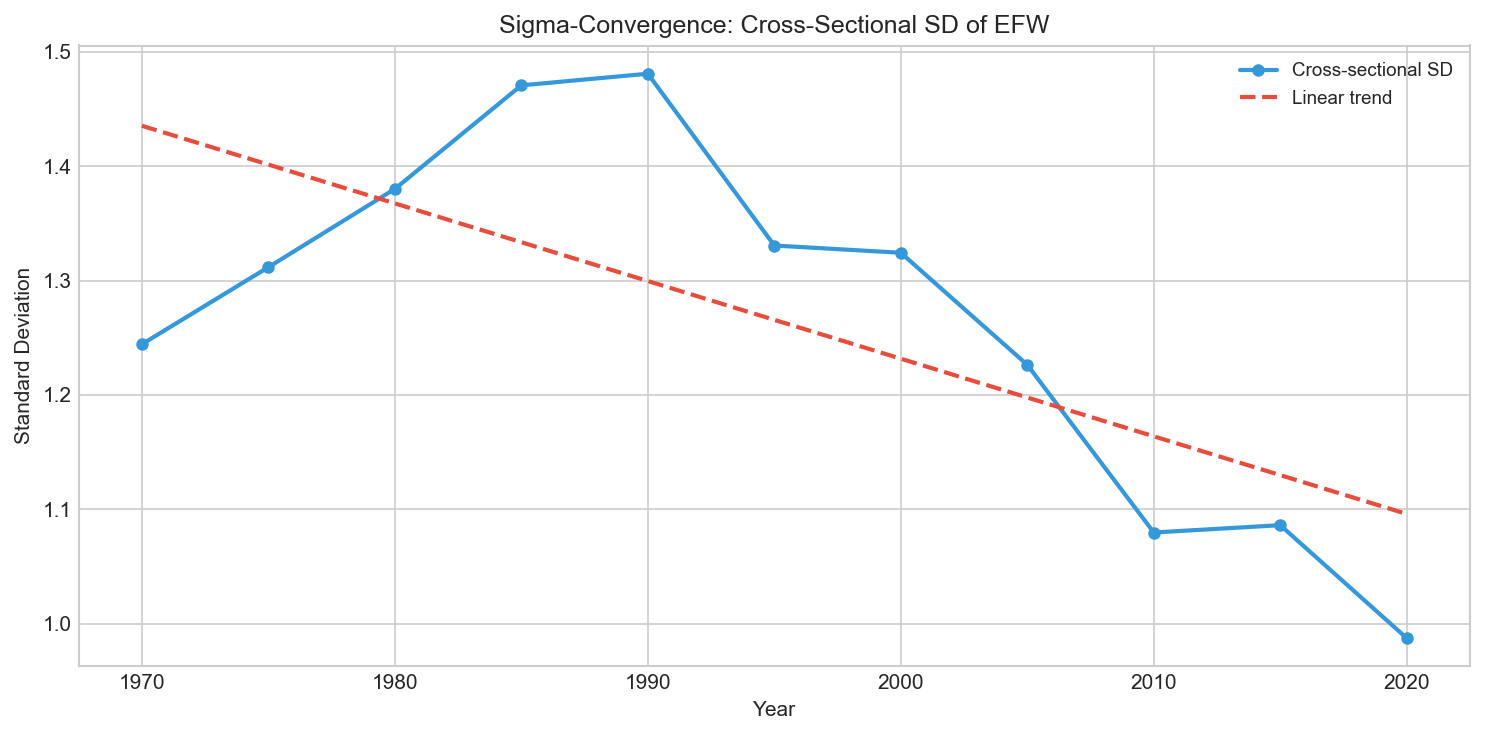

In [20]:
print("\n" + "=" * 60)
print("SIGMA-CONVERGENCE")
print("=" * 60)

# Compute SD by year
sigma_all = df_analysis.groupby('year')[EFW_COL].agg(['std', 'count'])
sigma_all.columns = ['SD', 'N']

# Linear trend
years = sigma_all.index.astype(float).values
sd_vals = sigma_all['SD'].values
slope, intercept, r, p, se = stats.linregress(years, sd_vals)
sigma_all['Trend'] = intercept + slope * years

print(f"Sigma-convergence (all countries):")
print(f"  SD 1970: {sigma_all.loc[1970, 'SD']:.3f}")
print(f"  SD 2020: {sigma_all.loc[2020, 'SD']:.3f}")
print(f"  Trend slope: {slope*10:.4f} per decade (p={p:.4f})")
print(f"  Convergence: {'Yes' if slope < 0 and p < 0.05 else 'No (not significant)'}")

# Plot
fig = plots.plot_convergence(sigma_all, title='Sigma-Convergence: Cross-Sectional SD of EFW')
plots.savefig(fig, 'quin_sigma_convergence.png')
plt.show()

### 5.2 Beta-Convergence


BETA-CONVERGENCE
Countries with data at both 1970 and 2020: 98

Beta-convergence regression:
  β = -0.533 (SE = 0.074, p = 0.0000)
  R² = 0.351
  Convergence: Yes
Saved: outputs/figures/quin_beta_convergence.png


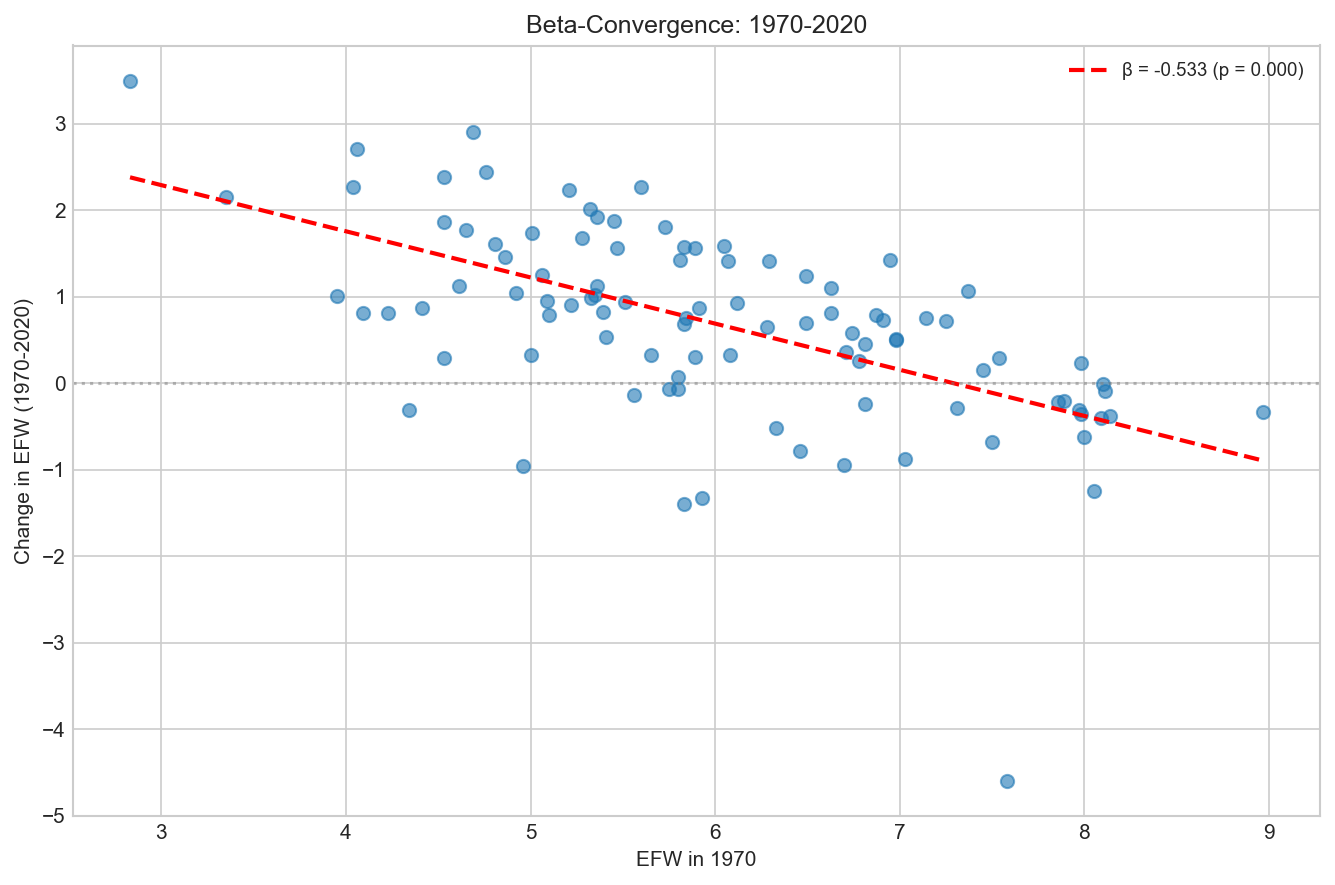

In [21]:
print("\n" + "=" * 60)
print("BETA-CONVERGENCE")
print("=" * 60)

# Get 1970 and 2020 values
start_year, end_year = 1970, 2020
df_start = df_analysis[df_analysis['year'] == start_year][['iso3', EFW_COL]].dropna()
df_end = df_analysis[df_analysis['year'] == end_year][['iso3', EFW_COL]].dropna()

df_beta = df_start.merge(df_end, on='iso3', suffixes=('_start', '_end'))
df_beta['change'] = df_beta[f'{EFW_COL}_end'] - df_beta[f'{EFW_COL}_start']
df_beta['initial'] = df_beta[f'{EFW_COL}_start']

print(f"Countries with data at both {start_year} and {end_year}: {len(df_beta)}")

if len(df_beta) > 5:
    # Regression
    slope, intercept, r, p, se = stats.linregress(df_beta['initial'], df_beta['change'])
    
    print(f"\nBeta-convergence regression:")
    print(f"  β = {slope:.3f} (SE = {se:.3f}, p = {p:.4f})")
    print(f"  R² = {r**2:.3f}")
    print(f"  Convergence: {'Yes' if slope < 0 and p < 0.05 else 'No'}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(df_beta['initial'], df_beta['change'], alpha=0.6, s=40)
    
    # Trend line
    x_line = np.linspace(df_beta['initial'].min(), df_beta['initial'].max(), 100)
    ax.plot(x_line, intercept + slope * x_line, 'r--', linewidth=2,
           label=f'β = {slope:.3f} (p = {p:.3f})')
    
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel(f'EFW in {start_year}')
    ax.set_ylabel(f'Change in EFW ({start_year}-{end_year})')
    ax.set_title(f'Beta-Convergence: {start_year}-{end_year}')
    ax.legend()
    plt.tight_layout()
    plots.savefig(fig, 'quin_beta_convergence.png')
    plt.show()

## 6. Mobility Analysis
### 6.1 Transition Matrix


TRANSITION MATRIX (QUINTILES)
Countries in transition matrix: 98

Transition Matrix (row %, 1970 → 2020):
Q_2020    Q1    Q2    Q3    Q4    Q5
Q_1970                              
Q1      25.0  15.0  10.0  40.0  10.0
Q2       0.0  10.5  26.3  42.1  21.1
Q3      10.0   0.0  25.0  30.0  35.0
Q4       0.0   0.0  21.1  15.8  63.2
Q5       5.0   0.0   0.0  15.0  80.0
Saved: outputs/tables/quin_transition_matrix.csv
Saved: outputs/figures/quin_transition_heatmap.png


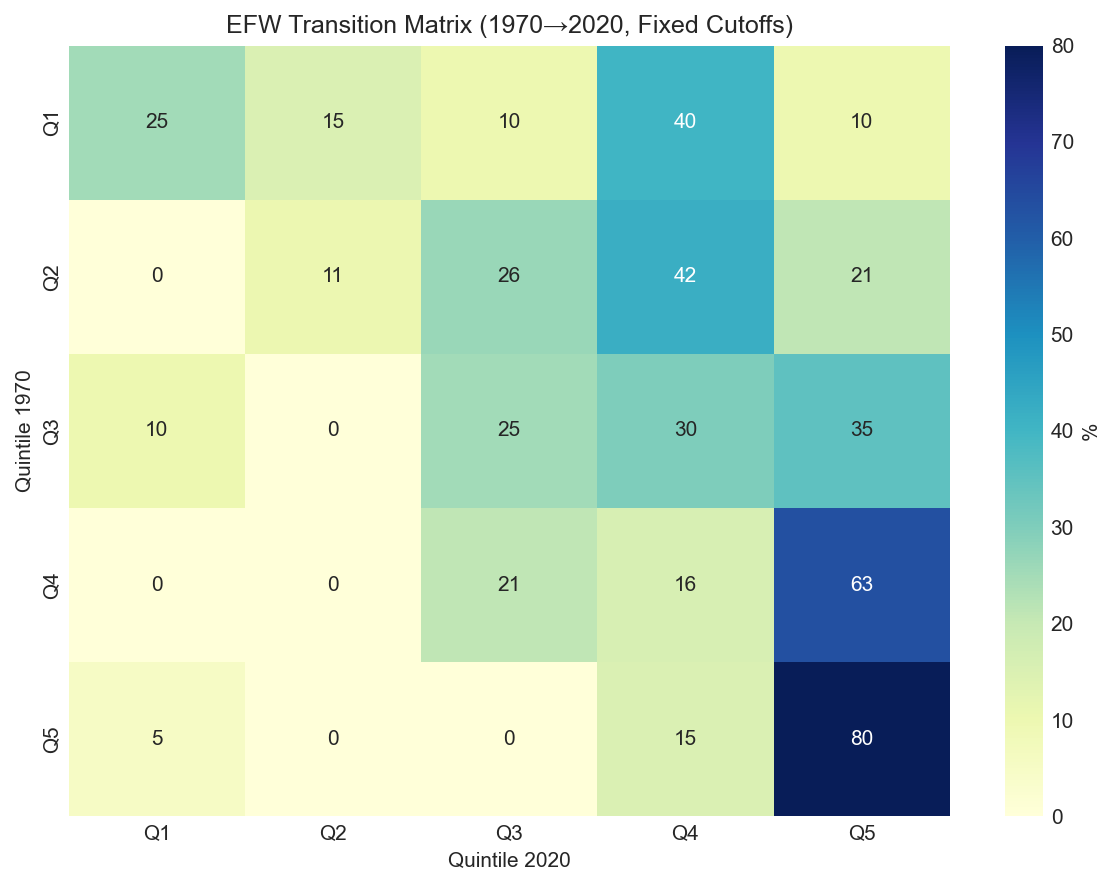

In [22]:
print("\n" + "=" * 60)
print("TRANSITION MATRIX (QUINTILES)")
print("=" * 60)

n_quantiles = 5
labels = [f'Q{i+1}' for i in range(n_quantiles)]

# Use 1970 cutoffs for consistent bins
df_start = df_analysis[df_analysis['year'] == 1970][['iso3', EFW_COL]].dropna()
df_end = df_analysis[df_analysis['year'] == 2020][['iso3', EFW_COL]].dropna()

_, bins_1970 = pd.qcut(df_start[EFW_COL], n_quantiles, labels=False, retbins=True)
bins = np.r_[-np.inf, bins_1970[1:-1], np.inf]

df_start['Q_1970'] = pd.cut(df_start[EFW_COL], bins=bins, labels=labels)
df_end['Q_2020'] = pd.cut(df_end[EFW_COL], bins=bins, labels=labels)

df_trans = df_start[['iso3', 'Q_1970']].merge(df_end[['iso3', 'Q_2020']], on='iso3')
print(f"Countries in transition matrix: {len(df_trans)}")

# Create transition matrix
trans_matrix = pd.crosstab(df_trans['Q_1970'], df_trans['Q_2020'], normalize='index') * 100
print("\nTransition Matrix (row %, 1970 → 2020):")
print(trans_matrix.round(1).to_string())
quality.save_table(trans_matrix.reset_index(), 'quin_transition_matrix')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(trans_matrix, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax,
           cbar_kws={'label': '%'})
ax.set_xlabel('Quintile 2020')
ax.set_ylabel('Quintile 1970')
ax.set_title('EFW Transition Matrix (1970→2020, Fixed Cutoffs)')
plt.tight_layout()
plots.savefig(fig, 'quin_transition_heatmap.png')
plt.show()

### 6.2 Rank Persistence


RANK PERSISTENCE
   period  spearman      p_value  n_countries
1970-1975  0.863070 3.126890e-30           98
1975-1980  0.884714 1.368137e-36          107
1980-1985  0.902683 2.375354e-41          110
1985-1990  0.911896 3.957938e-45          114
1990-1995  0.890115 4.701103e-41          117
1995-2000  0.923669 3.067714e-52          123
2000-2005  0.919864 2.717315e-65          158
2005-2010  0.932368 3.731817e-72          161
2010-2015  0.961661 8.261090e-92          162
2015-2020  0.958022 1.010616e-88          162
Saved: outputs/tables/quin_rank_persistence.csv
Saved: outputs/figures/quin_rank_persistence.png


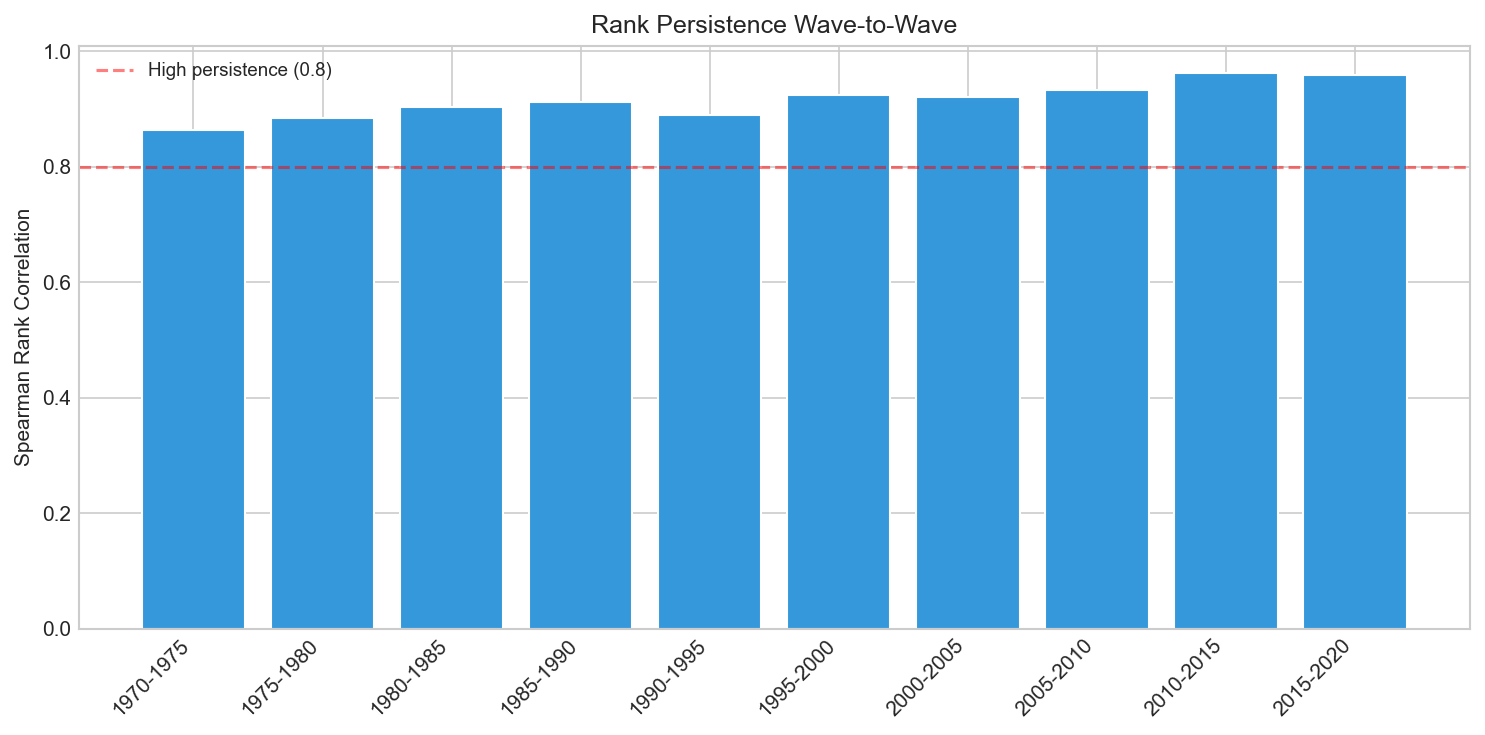

In [23]:
print("\n" + "=" * 60)
print("RANK PERSISTENCE")
print("=" * 60)

# Compute rank correlations wave-to-wave
rank_corrs = []
waves = sorted(df_analysis['year'].unique())

for i in range(len(waves) - 1):
    y1, y2 = waves[i], waves[i+1]
    d1 = df_analysis[df_analysis['year'] == y1][['iso3', EFW_COL]].dropna()
    d2 = df_analysis[df_analysis['year'] == y2][['iso3', EFW_COL]].dropna()
    merged = d1.merge(d2, on='iso3', suffixes=('_1', '_2'))
    
    if len(merged) > 5:
        spearman, p = stats.spearmanr(merged[f'{EFW_COL}_1'], merged[f'{EFW_COL}_2'])
        rank_corrs.append({
            'period': f'{y1}-{y2}',
            'spearman': spearman,
            'p_value': p,
            'n_countries': len(merged)
        })

rank_df = pd.DataFrame(rank_corrs)
print(rank_df.to_string(index=False))
quality.save_table(rank_df, 'quin_rank_persistence')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(rank_df)), rank_df['spearman'], color='#3498db', edgecolor='white')
ax.set_xticks(range(len(rank_df)))
ax.set_xticklabels(rank_df['period'], rotation=45, ha='right')
ax.set_ylabel('Spearman Rank Correlation')
ax.set_title('Rank Persistence Wave-to-Wave')
ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='High persistence (0.8)')
ax.legend()
plt.tight_layout()
plots.savefig(fig, 'quin_rank_persistence.png')
plt.show()

## 7. Macro-Conditioned Analysis

In [24]:
print("\n" + "=" * 60)
print("MACRO-CONDITIONED REFORM ANALYSIS")
print("=" * 60)

# Merge with macro for conditioning
df_macro_merged = samples['efw_any_macro'].copy()
print(f"Sample with EFW + macro: {len(df_macro_merged):,}")


MACRO-CONDITIONED REFORM ANALYSIS
Sample with EFW + macro: 1,477


### 7.1 EFW Change by Inflation Regime


EFW Change by 1990 Inflation Quartile:
               Δ EFW Mean  Δ EFW Median   N  Median Inflation
infl_quartile                                                
Low                  0.09         -0.05  26              2.22
Med-Low              0.48          0.56  26              5.89
Med-High             1.01          1.05  25             14.55
High                 1.89          2.02  26             58.70
Saved: outputs/tables/quin_efw_by_inflation.csv
Saved: outputs/figures/quin_efw_by_inflation.png


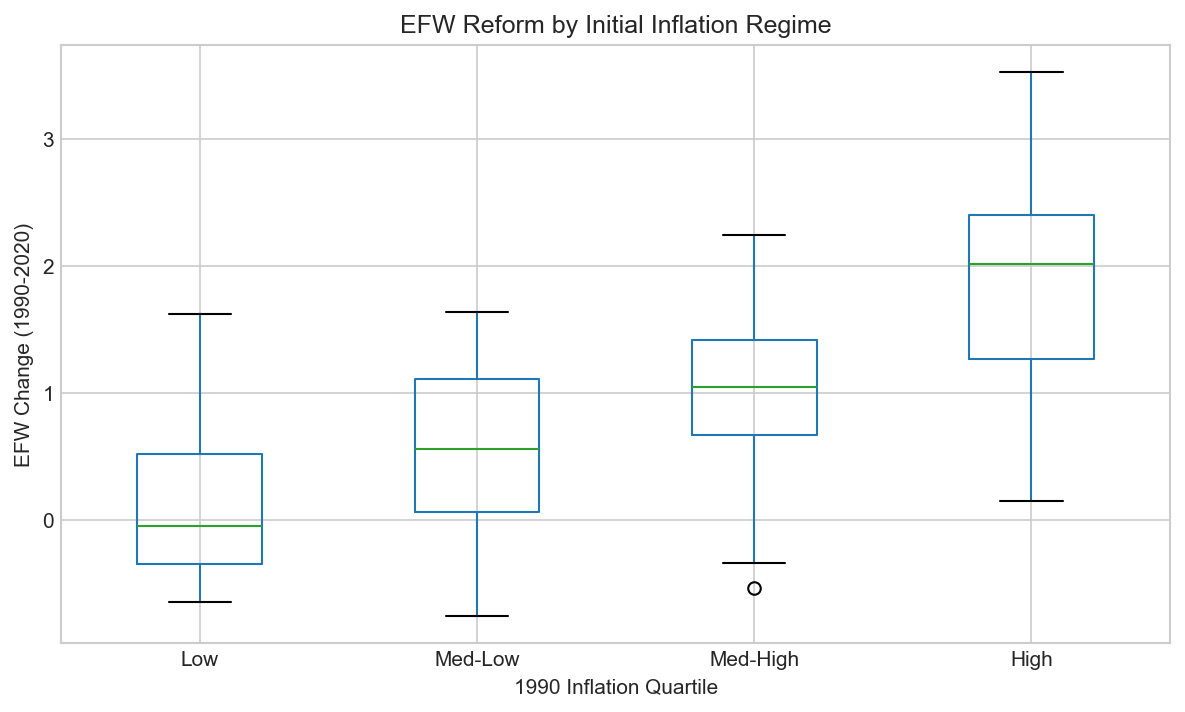

In [25]:
# Compute EFW changes 1990-2020
y1, y2 = 1990, 2020
df_1990 = df_macro_merged[df_macro_merged['year'] == y1][['iso3', EFW_COL, 'FP.CPI.TOTL.ZG']].dropna()
df_2020 = df_macro_merged[df_macro_merged['year'] == y2][['iso3', EFW_COL]].dropna()

df_change = df_1990.merge(df_2020, on='iso3', suffixes=('_1990', '_2020'))
df_change['efw_change'] = df_change[f'{EFW_COL}_2020'] - df_change[f'{EFW_COL}_1990']

if 'FP.CPI.TOTL.ZG' in df_change.columns and len(df_change) > 10:
    # Quartiles based on 1990 inflation
    df_change['infl_quartile'] = pd.qcut(
        df_change['FP.CPI.TOTL.ZG'].clip(-10, 200), 
        4, labels=['Low', 'Med-Low', 'Med-High', 'High']
    )
    
    print("\nEFW Change by 1990 Inflation Quartile:")
    infl_summary = df_change.groupby('infl_quartile').agg({
        'efw_change': ['mean', 'median', 'count'],
        'FP.CPI.TOTL.ZG': 'median'
    })
    infl_summary.columns = ['Δ EFW Mean', 'Δ EFW Median', 'N', 'Median Inflation']
    print(infl_summary.round(2).to_string())
    quality.save_table(infl_summary.reset_index(), 'quin_efw_by_inflation')
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    df_change.boxplot(column='efw_change', by='infl_quartile', ax=ax)
    ax.set_xlabel('1990 Inflation Quartile')
    ax.set_ylabel('EFW Change (1990-2020)')
    ax.set_title('EFW Reform by Initial Inflation Regime')
    plt.suptitle('')
    plt.tight_layout()
    plots.savefig(fig, 'quin_efw_by_inflation.png')
    plt.show()

### 7.2 EFW Change by Growth Regime

In [26]:
if 'NY.GDP.MKTP.KD.ZG' in df_macro_merged.columns:
    # Average growth 1990-2020
    growth_avg = df_macro_merged.groupby('iso3')['NY.GDP.MKTP.KD.ZG'].mean()
    df_change['avg_growth'] = df_change['iso3'].map(growth_avg)
    
    if df_change['avg_growth'].notna().sum() > 10:
        df_change['growth_quartile'] = pd.qcut(
            df_change['avg_growth'], 4, 
            labels=['Low', 'Med-Low', 'Med-High', 'High']
        )
        
        print("\nEFW Change by Average Growth Quartile (1990-2020):")
        growth_summary = df_change.groupby('growth_quartile').agg({
            'efw_change': ['mean', 'median', 'count'],
            'avg_growth': 'median'
        })
        growth_summary.columns = ['Δ EFW Mean', 'Δ EFW Median', 'N', 'Median Growth']
        print(growth_summary.round(2).to_string())
        quality.save_table(growth_summary.reset_index(), 'quin_efw_by_growth')


EFW Change by Average Growth Quartile (1990-2020):
                 Δ EFW Mean  Δ EFW Median   N  Median Growth
growth_quartile                                             
Low                    0.65          0.28  26           2.06
Med-Low                0.66          0.55  26           2.83
Med-High               0.95          1.13  25           3.90
High                   1.21          1.18  26           5.31
Saved: outputs/tables/quin_efw_by_growth.csv


## 8. Balanced Panel Sensitivity

In [27]:
print("\n" + "=" * 60)
print("BALANCED PANEL SENSITIVITY")
print("=" * 60)

if len(df_balanced) > 0:
    # Sigma-convergence on balanced panel
    sigma_bal = df_balanced.groupby('year')[EFW_COL].std()
    
    print(f"Balanced panel: {df_balanced['iso3'].nunique()} countries")
    print(f"\nSigma-convergence comparison:")
    print(f"  {'Year':<6} {'All Sample':>12} {'Balanced':>12}")
    for year in [1970, 1990, 2000, 2020]:
        if year in sigma_all.index:
            all_sd = sigma_all.loc[year, 'SD']
            bal_sd = sigma_bal.get(year, np.nan)
            print(f"  {year:<6} {all_sd:>12.3f} {bal_sd:>12.3f}")
    
    # Beta-convergence on balanced
    df_bal_start = df_balanced[df_balanced['year'] == 1970][['iso3', EFW_COL]]
    df_bal_end = df_balanced[df_balanced['year'] == 2020][['iso3', EFW_COL]]
    df_bal_beta = df_bal_start.merge(df_bal_end, on='iso3', suffixes=('_1970', '_2020'))
    df_bal_beta['change'] = df_bal_beta[f'{EFW_COL}_2020'] - df_bal_beta[f'{EFW_COL}_1970']
    
    if len(df_bal_beta) > 5:
        slope_bal, _, r_bal, p_bal, _ = stats.linregress(
            df_bal_beta[f'{EFW_COL}_1970'], df_bal_beta['change']
        )
        print(f"\nBeta-convergence (balanced): β = {slope_bal:.3f} (p = {p_bal:.4f})")


BALANCED PANEL SENSITIVITY
Balanced panel: 98 countries

Sigma-convergence comparison:
  Year     All Sample     Balanced
  1970          1.244        1.244
  1990          1.481        1.498
  2000          1.324        1.246
  2020          0.988        1.074

Beta-convergence (balanced): β = -0.533 (p = 0.0000)


## 9. Summary

In [28]:
print("\n" + "=" * 70)
print("QUINQUENNIAL EDA COMPLETE")
print("=" * 70)

print(f"""
Analysis Period: {QUINQUENNIAL_YEARS[0]}-{QUINQUENNIAL_YEARS[-1]}
Waves: {len(QUINQUENNIAL_YEARS)}
Primary Sample: {len(df_analysis):,} observations
Countries (all waves): {df_analysis['iso3'].nunique()}
Balanced Countries: {df_balanced['iso3'].nunique() if len(df_balanced) > 0 else 0}

Key Findings:
- σ-Convergence: {'Yes' if slope < 0 else 'No'} (slope = {slope*10:.3f}/decade)
- β-Convergence: Tested on {len(df_beta) if 'df_beta' in dir() else 0} countries
- Rank persistence: High (Spearman > 0.8 across most waves)

Outputs saved to:
- outputs/figures/
- outputs/tables/
""")


QUINQUENNIAL EDA COMPLETE

Analysis Period: 1970-2020
Waves: 11
Primary Sample: 1,477 observations
Countries (all waves): 165
Balanced Countries: 98

Key Findings:
- σ-Convergence: Yes (slope = -5.334/decade)
- β-Convergence: Tested on 98 countries
- Rank persistence: High (Spearman > 0.8 across most waves)

Outputs saved to:
- outputs/figures/
- outputs/tables/

